In [166]:
####################################
#ENVIRONMENT SETUP

In [167]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import pandas as pd
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime, timedelta

In [168]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [169]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data")
dataType = "RainfallHistogram"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP/_RainfallHistogram/testing



In [170]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [171]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import FigurePlotting_Class

In [172]:
#Setup

Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
# Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

In [173]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = (Region,Case,"TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 241/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs/history_cartesian/history.2022-06-05_12.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs/diag_cartesian/diag.2022-06-05_12.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         PRECIP
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-05 to 2022-06-08
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:241
 # Diag Files:   241
 # Time Steps:   241
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs
 Static File:    PRECIP_regional5500_scale

In [174]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSubsetting import DataSubsetting_Class

In [175]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [176]:
#IMPORT FUNCTIONS
# --- Add your Functions folder to sys.path ---
import sys
path = os.path.join(DirectoryManager.mainCodeDirectory, 'Functions_2.0')
sys.path.append(path)


# --- Import all your function modules ---
import importlib
modules = [
    "AreaAverageFunctions",
    "ComputationFunctions",
    "DataFunctions",
    "DerivativeFunctions",
    "PlottingFunctions",
    "StatisticalFunctions",
]
for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [177]:
####################################
#GETTING PRECIP DATA

In [178]:
def CorrectSimulationDates(ModelData, simulationDates):
    if int(ModelData.spinup_hours) <= 0:
        # Convert first date to Timestamp
        first_date = pd.to_datetime(simulationDates[0])
        # Subtract one day
        prev_date = (first_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        # Prepend
        simulationDates = [prev_date] + simulationDates
    return simulationDates

def GetPRECIP_QPE_DataDirectory(ModelData):
    simulationDates = ModelData.simulationDates
    simulationDates2 = CorrectSimulationDates(ModelData, simulationDates)

    inputDirectory = os.path.join(DirectoryManager.dataDirectory,
             f"Observation_Data/PRECIP/QPE1HR", ModelData.case)
    return inputDirectory

import gzip
import struct

def BuildQPELonLat(nx, ny):
    dx = 12.5 / 1000.0  # degrees

    lon0 = 118.0
    lat0 = 27.0

    lon = lon0 + dx * np.arange(nx)
    lat = lat0 - dx * np.arange(ny)

    qpeLon, qpeLat = np.meshgrid(lon, lat)

    return qpeLon, qpeLat
    
def ReadQPEData(filePath):
    with gzip.open(filePath, "rb") as f:
        raw = f.read()

    # read nx, ny from first 32 bytes
    header_part1 = raw[:32]
    year, month, day, hour, minute, second, nx, ny = struct.unpack("<8i", header_part1)
    # header_part2 = raw[32:48]
    # lon0, lat0, dx_lon, dx_lat = struct.unpack("<4f", header_part2)

    nvals = nx * ny
    rain_bytes = nvals * 2  # int16 = 2 bytes

    # rainfall is last part of file
    rain_start = len(raw) - rain_bytes

    # read int16 array
    rain = np.frombuffer(raw[rain_start:], dtype="<i2")

    # reshape to grid
    rain = rain.reshape(ny, nx)

    #converting data from 0.1mm to mm
    rain = rain / 1e1
    #removing nans
    rain[rain<0] = np.nan
    return rain, nx,ny 

# def GetPreviousHourQPEFiles(yearmonthdayhour, inputDirectory):
#     """
#     yearmonthdayhour : 'YYYYMMDDHH'
#     returns list of full file paths covering the previous hour
#     """

#     targetTime = pd.to_datetime(yearmonthdayhour, format="%Y%m%d%H")
#     startTime  = targetTime - pd.Timedelta(hours=1)

#     yearmonthday = targetTime.strftime("%Y%m%d")
#     inputFolder = os.path.join(inputDirectory, yearmonthday)

#     fileList = []

#     currentTime = startTime + pd.Timedelta(minutes=10)
#     while currentTime <= targetTime:
#         timestamp = currentTime.strftime("%H%M")
#         fileName = f"CB_GC_PCP_1H_RAD.{yearmonthday}.{timestamp}.gz"
#         fullPath = os.path.join(inputFolder, fileName)

#         if os.path.exists(fullPath):
#             fileList.append(fullPath)

#         currentTime += pd.Timedelta(minutes=10)

#     return sorted(fileList)
# fileList = GetPreviousHourQPEFiles(yearmonthdayhour, inputDirectory) #incorrect since each 10 minute file is accumulation of past horu

def ReadPrecipData_PRECIP_QPE(ModelData,yearmonthdayhour,inputDirectory):
    yearmonthday = yearmonthdayhour[0:8]
    hour = yearmonthdayhour[8:]
    inputFolder = os.path.join(inputDirectory,yearmonthday)
    filePath = os.path.join(inputFolder, f"CB_GC_PCP_1H_RAD.{yearmonthday}.{hour}00.gz")

    precipData,qpeLon,qpeLat = ReadQPEData(filePath)
    return precipData, qpeLon,qpeLat

In [179]:
def GetAccumulatedPrecipData_PRECIP_QPE(ModelData): 
    #getting inputDirectory
    inputDirectory = GetPRECIP_QPE_DataDirectory(ModelData)
    print(f"reading from {inputDirectory}")

    #getting yearmonthdayhour list
    dt_list = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in ModelData.timeStrings]
    start = dt_list[0]
    target = start + timedelta(hours=13)
    # print(f"start_time: {target}")
    
    # Find the entry closest to +12 hours
    closest = min(dt_list, key=lambda x: abs(x - target))
    
    closest_idx = dt_list.index(closest)
    times = ModelData.timeStrings[closest_idx:]
    yearmonthdayhours = sorted({t.replace('-', '').replace('_', '').replace('.', '')[:10] 
                                for t in times})

    precipData_T = None
    for count, yearmonthdayhour in tqdm(enumerate(yearmonthdayhours), total=len(yearmonthdayhours)):
        # print(yearmonthdayhour)
        
        precipData,nx,ny = ReadPrecipData_PRECIP_QPE(ModelData,yearmonthdayhour,inputDirectory)
        if precipData is None:
            continue #skips missing hours
        if precipData_T is None:
            precipData_T = precipData #equates at first timestep
        else:
            precipData_T += precipData

    qpeLon,qpeLat = BuildQPELonLat(nx,ny)
    return precipData_T, qpeLon,qpeLat

In [180]:
[precipData_T,qpeLon,qpeLat] = GetAccumulatedPrecipData_PRECIP_QPE(ModelData_NSSL)

reading from /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/QPE1HR/WET


100%|██████████| 48/48 [00:00<00:00, 500.95it/s]


In [181]:
data = ModelData_NSSL.GetDataTimestep(t=ModelData.Ntime-1)
modelRain = data["rainnc"]+data["rainc"]
modelRainLongitude = modelRain.longitude
modelRainLatitude = modelRain.latitude

Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/WET/MPAS-Model_NSSL/model_run_spinup12hrs/history_cartesian/history.2022-06-08_00.00.00.latlon.nc


In [182]:
################
#SINGELE PLOTS
################

In [183]:
# # import matplotlib.pyplot as plt
# # import cartopy.crs as ccrs
# # import cartopy.feature as cfeature


# fig = plt.figure(figsize=(10, 8))

# ax = plt.axes(projection=ccrs.PlateCarree())

# cf = ax.contourf(
#     qpeLon,
#     qpeLat,
#     precipData_T,
#     levels=20,
#     transform=ccrs.PlateCarree(),
#     cmap="turbo"
# )

# # --- Map features ---
# ax.coastlines(resolution="10m", linewidth=1.2)
# ax.add_feature(cfeature.BORDERS, linewidth=1.0)
# ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
# ax.add_feature(cfeature.OCEAN, facecolor="none")

# # Optional: Taiwan outline looks better with this
# ax.add_feature(cfeature.STATES, linewidth=0.5)

# # --- Domain bounds (important!) ---
# ax.set_extent(
#     [qpeLon.min(), qpeLon.max(), qpeLat.min(), qpeLat.max()],
#     crs=ccrs.PlateCarree()
# )

# plt.colorbar(cf, ax=ax, label="Rainfall (mm)")



# gl = ax.gridlines(
#     crs=ccrs.PlateCarree(),
#     draw_labels=True,
#     linewidth=0.8,
#     color="gray",
#     alpha=0.6,
#     linestyle="--"
# )

# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {"size": 11}
# gl.ylabel_style = {"size": 11}

In [184]:
# fig = plt.figure(figsize=(10, 8))

# ax = plt.axes(projection=ccrs.PlateCarree())

# cf = ax.contourf(
#     modelRainLongitude,
#     modelRainLatitude,
#     modelRain,
#     levels=20,
#     transform=ccrs.PlateCarree(),
#     cmap="turbo"
# )

# # --- Map features ---
# ax.coastlines(resolution="10m", linewidth=1.2)
# ax.add_feature(cfeature.BORDERS, linewidth=1.0)
# ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
# ax.add_feature(cfeature.OCEAN, facecolor="none")

# # Optional: Taiwan outline looks better with this
# ax.add_feature(cfeature.STATES, linewidth=0.5)

# # --- Domain bounds (important!) ---
# ax.set_extent(
#     [modelRainLongitude.min(), modelRainLongitude.max(), modelRainLatitude.min(), modelRainLatitude.max()],
#     crs=ccrs.PlateCarree()
# )

# plt.colorbar(cf, ax=ax, label="Rainfall (mm)")

# gl = ax.gridlines(
#     crs=ccrs.PlateCarree(),
#     draw_labels=True,
#     linewidth=0.8,
#     color="gray",
#     alpha=0.6,
#     linestyle="--"
# )

# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {"size": 11}
# gl.ylabel_style = {"size": 11}

In [185]:
################
#COMBINING PLOTS
################

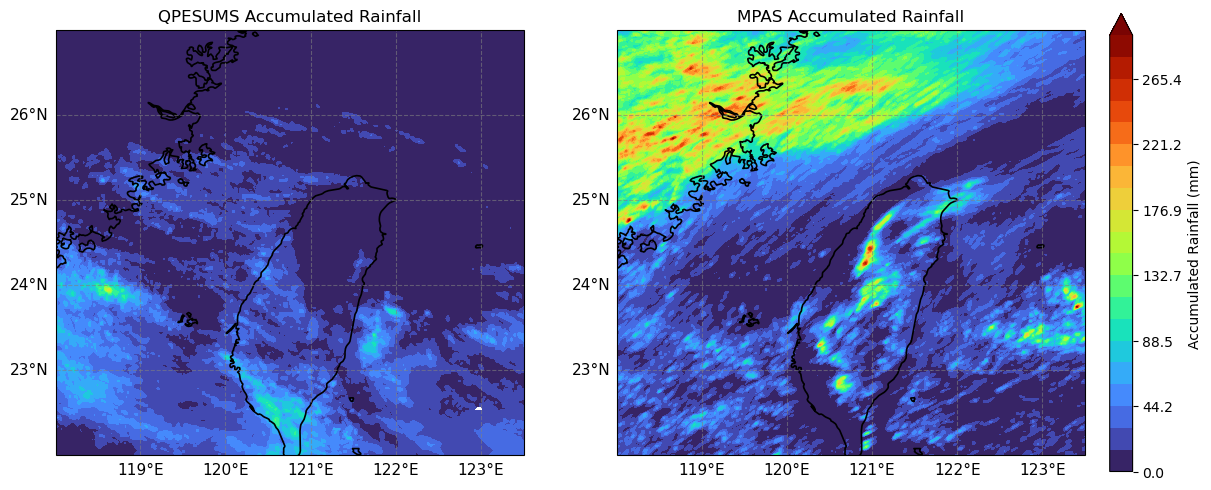

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create figure and axes
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax_qpe, ax_model = axes


# Shared color scale

vmin = np.nanmin([np.nanmin(precipData_T), np.nanmin(modelRain)])
vmax = np.nanmax([np.nanmax(precipData_T), np.nanmax(modelRain)])
levels = np.linspace(vmin, vmax, 21)

# PRECIP QPE panel
cf_qpe = ax_qpe.contourf(
    qpeLon,
    qpeLat,
    precipData_T,
    levels=levels,
    cmap="turbo",
    transform=ccrs.PlateCarree(),
    extend="max"
)

ax_qpe.set_title("QPESUMS Accumulated Rainfall")

# Model panel
cf_model = ax_model.contourf(
    modelRainLongitude,
    modelRainLatitude,
    modelRain,
    levels=levels,
    cmap="turbo",
    transform=ccrs.PlateCarree(),
    extend="max"
)

ax_model.set_title("MPAS Accumulated Rainfall")


#SET EXTENT
def DecorateMap(ax, extent):
    ax.coastlines(resolution="10m", linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linewidth=1.0)
    ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="none")

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 11}
    gl.ylabel_style = {"size": 11}

lon_min = max(qpeLon.min(), modelRainLongitude.min())
lon_max = min(qpeLon.max(), modelRainLongitude.max())

lat_min = max(qpeLat.min(), modelRainLatitude.min())
lat_max = min(qpeLat.max(), modelRainLatitude.max())

commonExtent = [lon_min, lon_max, lat_min, lat_max]
DecorateMap(ax_qpe, commonExtent)
DecorateMap(ax_model, commonExtent)

# Shared colorbar
cbar = fig.colorbar(
    cf_qpe,
    ax=axes,
    orientation="vertical",
    pad=0.02,
    shrink=0.85
)
cbar.set_label("Accumulated Rainfall (mm)")

In [ ]:
#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*
#IMPORTANT NOTE: Likely the data is not correct or is not being read correctly. The data barely matches and the precipitation patterns don't make physical sense and don't match well with radar data (observed precipitation should be mostly over the north of the island.
#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*#*